In [ ]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.append("../GNN-model")
from delay_model import RouteNet_Fermi


tf.random.set_seed(7)
np.random.seed(7)


def build_toy_sample():
    inputs = {
        "traffic": np.array([[1385.4059]], dtype=np.float32),
        "packets": np.array([[1.4015231]], dtype=np.float32),
        "length": np.array([1], dtype=np.int32),
        "model": np.array([1], dtype=np.int32),
        "eq_lambda": np.array([[1350.9712]], dtype=np.float32),
        "avg_pkts_lambda": np.array([[0.9117304]], dtype=np.float32),
        "exp_max_factor": np.array([[6.6636376]], dtype=np.float32),
        "pkts_lambda_on": np.array([[0.9116323]], dtype=np.float32),
        "avg_t_off": np.array([[1.6649284]], dtype=np.float32),
        "avg_t_on": np.array([[1.6649284]], dtype=np.float32),
        "ar_a": np.array([[0.0]], dtype=np.float32),
        "sigma": np.array([[0.0]], dtype=np.float32),
        "capacity": np.array([[27611.092]], dtype=np.float32),
        "queue_size": np.array([[30259.105]], dtype=np.float32),
        "policy": np.array([0], dtype=np.int32),
        "priority": np.array([0], dtype=np.int32),
        "weight": np.array([[1.0]], dtype=np.float32),
        "link_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
        "queue_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
        "queue_to_link": tf.ragged.constant([[0]], dtype=tf.int32),
        "path_to_queue": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
        "path_to_link": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
    }
    target = tf.constant([123.456], dtype=tf.float32)
    return inputs, target


sample_input, sample_target = build_toy_sample()
model = RouteNet_Fermi()
_ = model(sample_input, training=False)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
loss_fn = tf.keras.losses.MeanSquaredError()

losses = []
print("Entrenando una muestra hecha a mano...")
for step in range(300):
    with tf.GradientTape() as tape:
        prediction = model(sample_input, training=True)
        loss = loss_fn(sample_target, prediction)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    losses.append(float(loss.numpy()))
    if step % 25 == 0:
        print(f"Paso {step:03d}: loss={loss.numpy():.10f}, pred={float(tf.reduce_mean(prediction).numpy()):.6f}")

final_prediction = model(sample_input, training=False)
print(f"Loss inicial: {losses[0]:.10f}")
print(f"Loss final:   {losses[-1]:.10f}")
print(f"Target absurdo:   {float(sample_target.numpy()[0]):.6f}")
print(f"Predicción final: {float(tf.reduce_mean(final_prediction).numpy()):.6f}")

plt.figure(figsize=(7, 4))
plt.plot(losses, linewidth=2)
plt.yscale("log")
plt.xlabel("Paso")
plt.ylabel("Loss")
plt.title("Prueba tonta de memorización manual")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
# Ajusta esta ruta a tu entorno
sys.path.append("../GNN-model") 
from delay_model import RouteNet_Fermi

# Fijar semillas para reproducibilidad total
tf.random.set_seed(42)
np.random.seed(42)

def build_toy_sample():
    # Estructura mínima: 1 Path, 1 Link, 1 Queue
    inputs = {
        "traffic": np.array([[1000.0]], dtype=np.float32),
        "packets": np.array([[1.0]], dtype=np.float32),
        "length": np.array([1], dtype=np.int32),
        "model": np.array([1], dtype=np.int32),
        "eq_lambda": np.array([[1000.0]], dtype=np.float32),
        "avg_pkts_lambda": np.array([[1.0]], dtype=np.float32),
        "exp_max_factor": np.array([[1.0]], dtype=np.float32),
        "pkts_lambda_on": np.array([[1.0]], dtype=np.float32),
        "avg_t_off": np.array([[1.0]], dtype=np.float32),
        "avg_t_on": np.array([[1.0]], dtype=np.float32),
        "ar_a": np.array([[0.0]], dtype=np.float32),
        "sigma": np.array([[0.0]], dtype=np.float32),
        "capacity": np.array([[10000.0]], dtype=np.float32),
        "queue_size": np.array([[5000.0]], dtype=np.float32),
        "policy": np.array([0], dtype=np.int32),
        "priority": np.array([0], dtype=np.int32),
        "weight": np.array([[1.0]], dtype=np.float32),
        # Conexiones mínimas
        "link_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
        "queue_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
        "queue_to_link": tf.ragged.constant([[0]], dtype=tf.int32),
        "path_to_queue": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
        "path_to_link": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
    }
    # Un target aleatorio para obligar al modelo a moverse
    target = tf.constant([0.5], dtype=tf.float32)
    return inputs, target

# Configuración
sample_input, sample_target = build_toy_sample()
model = RouteNet_Fermi()
# Ver configuración detallada de la primera capa densa
config = model.layers[0].get_config()
print(config['kernel_initializer'])
# Optimizer con un Learning Rate un poco más agresivo para este test
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
loss_fn = tf.keras.losses.MeanSquaredError()

losses = []
preds = []

print("--- INICIANDO TEST DE MEMORIZACIÓN ---")
for step in range(301):
    with tf.GradientTape() as tape:
        prediction = model(sample_input, training=True)
        loss = loss_fn(sample_target, prediction)
    
    gradients = tape.gradient(loss, model.trainable_variables)
    
    # Chequeo de seguridad: ¿Hay gradientes?
    if step == 0 and all(g is None for g in gradients):
        print("¡ERROR CRÍTICO!: Los gradientes son None. La cadena de diferenciación está rota.")
        break

    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    losses.append(loss.numpy())
    preds.append(tf.reduce_mean(prediction).numpy())
    
    if step % 50 == 0:
        print(f"Paso {step:03d} | Loss: {loss.numpy():.8f} | Pred: {preds[-1]:.6f}")

# --- RESULTADOS ---
print("\n--- RESULTADO FINAL ---")
print(f"Target deseado: {sample_target.numpy()[0]:.6f}")
print(f"Última predicción: {preds[-1]:.6f}")

# Visualización Doble
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss
ax1.plot(losses, color='tab:blue', linewidth=2)
ax1.set_yscale('log')
ax1.set_title("Evolución del Error (MSE)")
ax1.set_xlabel("Paso")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

# Gráfico de Predicción vs Target
ax2.plot(preds, color='tab:orange', label='Predicción', linewidth=2)
ax2.axhline(y=sample_target.numpy()[0], color='tab:green', linestyle='--', label='Target')
ax2.set_title("Aproximación al Target")
ax2.set_xlabel("Paso")
ax2.set_ylabel("Valor")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from delay_model import RouteNet_Fermi
import os
# 1. Forzar a que no vea ninguna GPU (-1 significa ninguna)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# 2. Silenciar avisos de compilación y librerías dinámicas
# 0 = todos, 1 = no info, 2 = no warnings, 3 = solo errores
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.random.set_seed(42)
np.random.seed(42)
def build_scaled_samples():
    dataset_inputs = []
    dataset_targets = []
    
    # Muestra 0: Carga baja (Tráfico bajo, Capacidad alta)
    # Muestra 1: Carga media (Cerca de la media del z_score)
    # Muestra 2: Carga alta (Tráfico alto, Capacidad baja)
    
    scenarios = [
        {"traffic": 800.0,  "capacity": 40000.0, "target": 0.05}, # Poco retardo
        {"traffic": 1385.0, "capacity": 27000.0, "target": 0.15}, # Retardo medio
        {"traffic": 2200.0, "capacity": 15000.0, "target": 0.45}  # Retardo alto
    ]

    for i, s in enumerate(scenarios):
        inputs = {
            # Valores escalados basados en tus medias (1385, 1.4, etc.)
            "traffic": np.array([[s["traffic"]]], dtype=np.float32),
            "packets": np.array([[1.4]], dtype=np.float32),
            "length": np.array([1], dtype=np.int32),
            "model": np.array([1], dtype=np.int32),
            "eq_lambda": np.array([[s["traffic"] * 0.9]], dtype=np.float32),
            "avg_pkts_lambda": np.array([[0.9]], dtype=np.float32),
            "exp_max_factor": np.array([[6.6]], dtype=np.float32),
            "pkts_lambda_on": np.array([[0.9]], dtype=np.float32),
            "avg_t_off": np.array([[1.6]], dtype=np.float32),
            "avg_t_on": np.array([[1.6]], dtype=np.float32),
            "ar_a": np.array([[0.0]], dtype=np.float32),
            "sigma": np.array([[0.0]], dtype=np.float32),
            
            # Infraestructura
            "capacity": np.array([[s["capacity"]]], dtype=np.float32),
            "queue_size": np.array([[30000.0]], dtype=np.float32),
            "policy": np.array([0], dtype=np.int32),
            "priority": np.array([0], dtype=np.int32),
            "weight": np.array([[1.0]], dtype=np.float32),
            
            # Topología mínima (1 path, 1 link, 1 queue)
            "link_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
            "queue_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
            "queue_to_link": tf.ragged.constant([[0]], dtype=tf.int32),
            "path_to_queue": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
            "path_to_link": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
        }
        dataset_inputs.append(inputs)
        dataset_targets.append(tf.constant([s["target"]], dtype=tf.float32))
        
    return dataset_inputs, dataset_targets

# 2. Configuración
num_samples = 3
inputs_list, targets_list = build_scaled_samples()
model = RouteNet_Fermi()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)
loss_fn = tf.keras.losses.MeanAbsolutePercentageError()

history_loss = []

print(f"Entrenando con {num_samples} muestras distintas...")

for step in range(1000):
    step_loss = 0
    with tf.GradientTape() as tape:
        # En cada paso calculamos la pérdida acumulada de todas las muestras
        for i in range(num_samples):
            pred = model(inputs_list[i], training=True)
            step_loss += loss_fn(targets_list[i], pred)
        
        # Promediamos la pérdida
        total_loss = step_loss / num_samples
        
    gradients = tape.gradient(total_loss, model.trainable_variables)
    # print(f"Paso {step:03d} | Loss: {total_loss.numpy():.10f} | Grad Norm: {tf.linalg.global_norm(gradients):.4f}")
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    history_loss.append(total_loss.numpy())
    
    if step % 100 == 0:
        print(f"Paso {step:03d} | Loss Promedio: {total_loss.numpy():.10f}")

# 3. Verificación Final (CORREGIDA)
print("\n--- RESULTADOS FINALES ---")
for i in range(num_samples):
    final_pred = model(inputs_list[i], training=False)
    
    # Extraemos el valor escalar para que el formateo :.4f funcione
    target_val = float(targets_list[i].numpy().flatten()[0])
    pred_val = float(final_pred.numpy().flatten()[0])
    
    print(f"Muestra {i} | Target: {target_val:.4f} | Pred: {pred_val:.4f}")

plt.plot(history_loss)
# plt.yscale('log')
plt.title(f"Aprendizaje con {num_samples} muestras")
plt.xlabel("Paso")
plt.ylabel("Loss (MSE)")
plt.grid(True, alpha=0.3)
plt.show()

Entrenando con 3 muestras (Optimizador: Adam + Gradient Clipping)...


2026-04-15 19:29:54.537474: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:907] Skipping loop optimization for Merge node with control input: Assert_1/AssertGuard/branch_executed/_179


Paso 000 | MSE Loss: 74.5737075806
Paso 100 | MSE Loss: 73.9836502075
Paso 200 | MSE Loss: 72.2733535767
Paso 300 | MSE Loss: 69.4850234985
Paso 400 | MSE Loss: 65.4523010254
Paso 500 | MSE Loss: 59.9843101501
Paso 600 | MSE Loss: 52.8942871094
Paso 700 | MSE Loss: 43.9956474304
Paso 800 | MSE Loss: 33.1009788513
Paso 900 | MSE Loss: 31.9765014648

--- RESULTADOS FINALES ---


2026-04-15 19:32:18.629930: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:907] Skipping loop optimization for Merge node with control input: Assert_1/AssertGuard/branch_executed/_1027


Muestra 0 | Real: 0.0500 | Pred: 0.0500 | Error: 0.04%
Muestra 1 | Real: 0.1500 | Pred: 0.0895 | Error: 40.32%
Muestra 2 | Real: 0.4500 | Pred: 0.1999 | Error: 55.57%


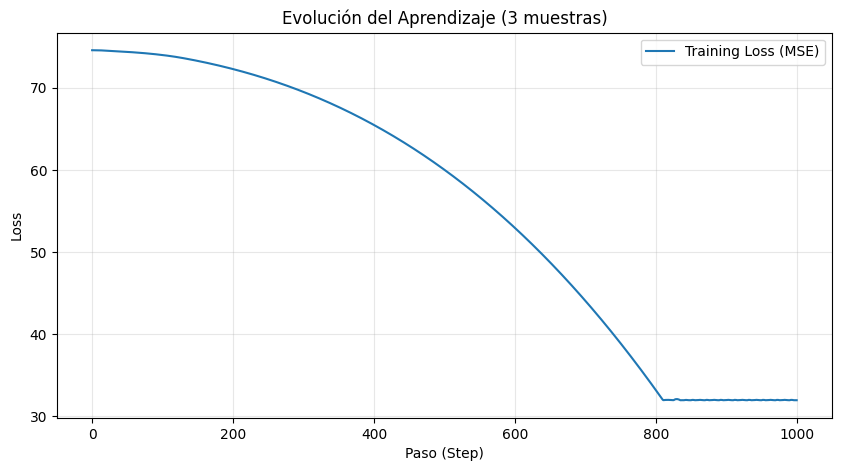

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from delay_model import RouteNet_Fermi
import os

# 1. Configuración de entorno
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import numpy as np
import random

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

def build_scaled_samples():
    dataset_inputs = []
    dataset_targets = []
    
    # Scenarios con targets un poco más "visibles" para el gradiente
    scenarios = [
        {"traffic": 800.0,  "capacity": 40000.0, "target": 0.05},
        {"traffic": 1385.0, "capacity": 27000.0, "target": 0.15},
        {"traffic": 2200.0, "capacity": 15000.0, "target": 0.45}
    ]

    for s in scenarios:
        inputs = {
            "traffic": np.array([[s["traffic"]]], dtype=np.float32),
            "packets": np.array([[1.4]], dtype=np.float32),
            "length": np.array([1], dtype=np.int32),
            "model": np.array([1], dtype=np.int32),
            "eq_lambda": np.array([[s["traffic"] * 0.9]], dtype=np.float32),
            "avg_pkts_lambda": np.array([[0.9]], dtype=np.float32),
            "exp_max_factor": np.array([[6.6]], dtype=np.float32),
            "pkts_lambda_on": np.array([[0.9]], dtype=np.float32),
            "avg_t_off": np.array([[1.6]], dtype=np.float32),
            "avg_t_on": np.array([[1.6]], dtype=np.float32),
            "ar_a": np.array([[0.0]], dtype=np.float32),
            "sigma": np.array([[0.0]], dtype=np.float32),
            "capacity": np.array([[s["capacity"]]], dtype=np.float32),
            "queue_size": np.array([[30000.0]], dtype=np.float32),
            "policy": np.array([0], dtype=np.int32),
            "priority": np.array([0], dtype=np.int32),
            "weight": np.array([[1.0]], dtype=np.float32),
            "link_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
            "queue_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
            "queue_to_link": tf.ragged.constant([[0]], dtype=tf.int32),
            "path_to_queue": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
            "path_to_link": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
        }
        dataset_inputs.append(inputs)
        dataset_targets.append(tf.constant([s["target"]], dtype=tf.float32))
        
    return dataset_inputs, dataset_targets

# 2. Inicialización
num_samples = 3
inputs_list, targets_list = build_scaled_samples()
model = RouteNet_Fermi()

# Optimizador con un Learning Rate algo más bajo para estabilidad
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

loss_fn = tf.keras.losses.MeanAbsolutePercentageError()

history_loss = []

print(f"Entrenando con {num_samples} muestras (Optimizador: Adam + Gradient Clipping)...")

# 3. Bucle de entrenamiento
for step in range(1000):
    with tf.GradientTape() as tape:
        total_loss = 0
        for i in range(num_samples):
            pred = model(inputs_list[i], training=True)
            # Calculamos pérdida sobre la muestra actual
            total_loss += loss_fn(targets_list[i], pred)
        
        # Promedio de la pérdida en el batch
        total_loss /= num_samples
        
    # Cálculo de gradientes
    gradients = tape.gradient(total_loss, model.trainable_variables)
    
    # --- MEJORA CLAVE: Gradient Clipping ---
    # Esto evita que los gradientes "exploten" o se vuelvan locos en la GNN
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
    
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    loss_val = total_loss.numpy()
    history_loss.append(loss_val)
    
    if step % 100 == 0:
        # Calculamos MAPE actual solo para información
        print(f"Paso {step:03d} | MSE Loss: {loss_val:.10f}")

# 4. Verificación Final
print("\n--- RESULTADOS FINALES ---")
for i in range(num_samples):
    final_pred = model(inputs_list[i], training=False)
    target_val = float(targets_list[i].numpy().flatten()[0])
    pred_val = float(final_pred.numpy().flatten()[0])
    error_porcentual = abs(target_val - pred_val) / target_val * 100
    
    print(f"Muestra {i} | Real: {target_val:.4f} | Pred: {pred_val:.4f} | Error: {error_porcentual:.2f}%")

# 5. Gráfica
plt.figure(figsize=(10, 5))
plt.plot(history_loss, label='Training Loss (MSE)')
plt.title(f"Evolución del Aprendizaje (3 muestras)")
plt.xlabel("Paso (Step)")
plt.ylabel("Loss")
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from delay_model import RouteNet_Fermi
# --- 1. Definición de la generación de datos (M/M/1) ---
def build_scaled_samples():
    dataset_inputs = []
    dataset_targets = []
    
    # Parámetros base
    # traffic / packets = bits por paquete. 
    # Usaremos un valor fijo de paquetes para este ejemplo
    avg_packets_val = 1.4 
    
    # Escenarios: (traffic en bits/s, capacity en bits/s)
    # Importante: traffic < capacity para que M/M/1 sea estable
    scenarios = [
        {"traffic": 1000.0,  "capacity": 10000.0}, # Carga 10%
        {"traffic": 5000.0,  "capacity": 10000.0}, # Carga 50%
        {"traffic": 8500.0,  "capacity": 10000.0}, # Carga 85%
        {"traffic": 15000.0, "capacity": 40000.0}, # Carga 37.5%
        {"traffic": 35000.0, "capacity": 40000.0}  # Carga 87.5%
    ]

    for s in scenarios:
        # Cálculo M/M/1:
        # Lambda (llegada de paquetes/s) = Tráfico total / Tamaño paquete
        # Mu (capacidad de servicio paquetes/s) = Capacidad total / Tamaño paquete
        # Retardo E[T] = 1 / (mu - lambda)
        
        packet_size_bits = s["traffic"] / avg_packets_val
        lam = s["traffic"] / packet_size_bits
        mu = s["capacity"] / packet_size_bits
        
        # Fórmula M/M/1
        target_delay = 1.0 / (mu - lam)

        inputs = {
            "traffic": np.array([[s["traffic"]]], dtype=np.float32),
            "packets": np.array([[avg_packets_val]], dtype=np.float32),
            "length": np.array([1], dtype=np.int32),
            "model": np.array([1], dtype=np.int32),
            "eq_lambda": np.array([[s["traffic"] * 0.9]], dtype=np.float32),
            "avg_pkts_lambda": np.array([[0.9]], dtype=np.float32),
            "exp_max_factor": np.array([[6.6]], dtype=np.float32),
            "pkts_lambda_on": np.array([[0.9]], dtype=np.float32),
            "avg_t_off": np.array([[1.6]], dtype=np.float32),
            "avg_t_on": np.array([[1.6]], dtype=np.float32),
            "ar_a": np.array([[0.0]], dtype=np.float32),
            "sigma": np.array([[0.0]], dtype=np.float32),
            "capacity": np.array([[s["capacity"]]], dtype=np.float32),
            "queue_size": np.array([[30000.0]], dtype=np.float32),
            "policy": np.array([0], dtype=np.int32),
            "priority": np.array([0], dtype=np.int32),
            "weight": np.array([[1.0]], dtype=np.float32),
            "link_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
            "queue_to_path": tf.ragged.constant([[0]], dtype=tf.int32),
            "queue_to_link": tf.ragged.constant([[0]], dtype=tf.int32),
            "path_to_queue": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
            "path_to_link": tf.ragged.constant([[[0, 0]]], dtype=tf.int32, ragged_rank=1),
        }
        dataset_inputs.append(inputs)
        dataset_targets.append(tf.constant([target_delay], dtype=tf.float32))
        
    return dataset_inputs, dataset_targets

# --- 2. Inicialización del Modelo y Optimizador ---
inputs_list, targets_list = build_scaled_samples()
num_samples = len(inputs_list)

# Asumiendo que RouteNet_Fermi ya está definida en tu entorno
model = RouteNet_Fermi()

# Optimizador Adam con Gradient Clipping integrado
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.MeanSquaredError() # MSE suele ser más estable para regresión inicial

history_loss = []

print(f"Entrenando con {num_samples} muestras (Objetivo: Retardo M/M/1)...")

# --- 3. Bucle de Entrenamiento ---
epochs = 1000
for step in range(epochs):
    with tf.GradientTape() as tape:
        total_loss = 0
        for i in range(num_samples):
            pred = model(inputs_list[i], training=True)
            total_loss += loss_fn(targets_list[i], pred)
        
        # Promedio de la pérdida
        avg_loss = total_loss / num_samples
        
    # Cálculo y aplicación de gradientes
    gradients = tape.gradient(avg_loss, model.trainable_variables)
    
    # # Gradient Clipping para evitar explosiones en la GNN
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    loss_val = avg_loss.numpy()
    history_loss.append(loss_val)
    
    if step % 100 == 0:
        print(f"Paso {step:03d} | Loss: {loss_val:.10f}")

# --- 4. Verificación de Resultados Finales ---
print("\n--- RESULTADOS FINALES (M/M/1 Validation) ---")
for i in range(num_samples):
    final_pred = model(inputs_list[i], training=False)
    target_val = float(targets_list[i].numpy().flatten()[0])
    pred_val = float(final_pred.numpy().flatten()[0])
    
    error_relativo = abs(target_val - pred_val) / target_val * 100
    
    print(f"Muestra {i} | Real: {target_val:.6f} | Pred: {pred_val:.6f} | Error: {error_relativo:.2f}%")

# --- 5. Visualización ---
plt.figure(figsize=(10, 5))
plt.plot(history_loss, color='blue', label='MSE Loss')
# plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.title("Evolución del Aprendizaje - Predicción Retardo M/M/1")
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

Entrenando con 5 muestras (Objetivo: Retardo M/M/1)...


/home/administrator/6gsenses/venv/lib/python3.7/site-packages/tensorflow/python/framework/indexed_slices.py:449: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradients/RaggedTile_1/GatherV2_1_grad/Reshape_1:0", shape=(None,), dtype=int64), values=Tensor("gradients/RaggedTile_1/GatherV2_1_grad/Reshape:0", shape=(None, 1), dtype=float32), dense_shape=Tensor("gradients/RaggedTile_1/GatherV2_1_grad/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
/home/administrator/6gsenses/venv/lib/python3.7/site-packages/tensorflow/python/framework/indexed_slices.py:449: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradients/RaggedGetItem_1/GatherV2_grad/Reshape_1:0", shape=(None,), dtype=int64), values=Tensor("gradients/RaggedGetItem_1/GatherV2_grad/Reshape:0", shape=(None, 32), dtype=float32), dense_shape=Tensor("gr

Paso 000 | Loss: 6.2261972427
Paso 100 | Loss: 6.2197599411
